<a href="https://www.kaggle.com/code/denizhangepdiremen/deepfake-image-detection-using-cnn?scriptVersionId=317918874" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [ ]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# GPU check
gpus = tf.config.list_physical_devices("GPU")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU count: {len(gpus)}")

# Dataset paths (Kaggle mounted this dataset under datasets/xhlulu/)
DATA_ROOT = "/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VALID_DIR = os.path.join(DATA_ROOT, "valid")
TEST_DIR  = os.path.join(DATA_ROOT, "test")

# Class distribution per split
print("\nClass distribution:")
for split_name, split_path in [("train", TRAIN_DIR), ("valid", VALID_DIR), ("test", TEST_DIR)]:
    classes = sorted(os.listdir(split_path))
    print(f"\n  {split_name}/  → classes: {classes}")
    for c in classes:
        n = len(os.listdir(os.path.join(split_path, c)))
        print(f"    {c}: {n} images")

In [ ]:
import random
from PIL import Image

# Show 5 real and 5 fake samples from training set
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for row, class_name in enumerate(["real", "fake"]):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    samples = random.sample(os.listdir(class_dir), 5)
    for col, fname in enumerate(samples):
        img = Image.open(os.path.join(class_dir, fname))
        axes[row, col].imshow(img)
        axes[row, col].set_title(class_name, fontsize=11)
        axes[row, col].axis("off")

plt.suptitle("Sample images from the training set (top: real, bottom: fake)", fontsize=13)
plt.tight_layout()
plt.show()

# Print image properties (needed for the report)
sample_path = os.path.join(TRAIN_DIR, "real", os.listdir(os.path.join(TRAIN_DIR, "real"))[0])
sample = Image.open(sample_path)
print(f"\nNative image size: {sample.size}")
print(f"Image mode: {sample.mode}")

In [ ]:
# Hyperparameters
IMG_SIZE = (160, 160)   # MobileNetV2 native input size
BATCH_SIZE = 64

# Build tf.data pipelines from directory structure.
# Explicit class ordering: fake=0, real=1
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    label_mode="binary",
    class_names=["fake", "real"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    label_mode="binary",
    class_names=["fake", "real"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    label_mode="binary",
    class_names=["fake", "real"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Performance: prefetch overlaps data loading with model training
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

print(f"Train batches: {len(train_ds)}  ({len(train_ds) * BATCH_SIZE} images)")
print(f"Valid batches: {len(valid_ds)}  ({len(valid_ds) * BATCH_SIZE} images)")
print(f"Test batches:  {len(test_ds)}  ({len(test_ds) * BATCH_SIZE} images)")

In [ ]:
# Conservative augmentation pipeline.
# Note: aggressive blur/noise/vertical flip would erase the high-frequency
# artifacts that distinguish StyleGAN fakes from real photos, so we keep
# transformations geometric/photometric and small in magnitude.
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),       # +/- 10% (about +/- 36 degrees)
    layers.RandomZoom(0.1),           # +/- 10%
    layers.RandomBrightness(0.1),     # +/- 10% brightness shift
    layers.RandomContrast(0.1),       # +/- 10% contrast
], name="data_augmentation")

# Visualize augmentation effect on a single sample (for the report)
plt.figure(figsize=(14, 6))
for images, labels in train_ds.take(1):
    sample = images[0]
    label = "real" if labels[0].numpy() == 1.0 else "fake"

    # Original
    plt.subplot(2, 4, 1)
    plt.imshow(sample.numpy().astype("uint8"))
    plt.title(f"Original ({label})", fontsize=10)
    plt.axis("off")

    # 7 different augmented versions of the same image
    for i in range(7):
        augmented = data_augmentation(tf.expand_dims(sample, 0), training=True)
        augmented = np.clip(augmented[0].numpy(), 0, 255).astype("uint8")
        plt.subplot(2, 4, i + 2)
        plt.imshow(augmented)
        plt.title(f"Augmented #{i + 1}", fontsize=10)
        plt.axis("off")

plt.suptitle("Effect of data augmentation on a single sample", fontsize=13)
plt.tight_layout()
plt.show()

print("\nAugmentation layer summary:")
data_augmentation.summary()

In [ ]:
def build_custom_cnn(input_shape=(160, 160, 3), augmentation=None):
    """
    Custom 4-block CNN for binary deepfake classification.

    Design rationale:
      - Progressive feature widening (32 -> 64 -> 128 -> 128) builds
        a hierarchy from low-level edges to high-level facial patterns.
      - BatchNorm after each Conv stabilizes training and acts as mild
        regularization.
      - GlobalAveragePooling replaces Flatten -> drastically fewer
        parameters in the head, which mitigates overfitting.
      - Two dropout layers in the dense head further reduce overfitting.
      - Sigmoid output for binary classification (fake=0, real=1).
    """
    inputs = keras.Input(shape=input_shape)
    x = inputs

    # Augmentation is applied only when training=True (handled by model.fit).
    if augmentation is not None:
        x = augmentation(x)

    # Normalize pixel values from [0, 255] to [0, 1].
    x = layers.Rescaling(1.0 / 255)(x)

    # ----- Convolutional feature extractor -----
    # Block 1: 32 filters, 160x160 -> 80x80
    x = layers.Conv2D(32, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 2: 64 filters, 80x80 -> 40x40
    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 3: 128 filters, 40x40 -> 20x20
    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 4: 128 filters, 20x20 -> 10x10
    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)

    # ----- Classification head -----
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return keras.Model(inputs, outputs, name="custom_cnn")


# Build and summarize the model
custom_cnn = build_custom_cnn(
    input_shape=(160, 160, 3),
    augmentation=data_augmentation,
)
custom_cnn.summary()

# Save an architecture diagram for the report
try:
    keras.utils.plot_model(
        custom_cnn,
        to_file="/kaggle/working/custom_cnn_architecture.png",
        show_shapes=True,
        show_layer_names=True,
        dpi=100,
    )
    print("\nArchitecture diagram saved to /kaggle/working/custom_cnn_architecture.png")
    from IPython.display import Image as IPImage
    display(IPImage("/kaggle/working/custom_cnn_architecture.png"))
except Exception as e:
    print(f"\nplot_model failed (graphviz missing?): {e}")
    print("Architecture summary above is sufficient for the report.")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Define architecture blocks: (label, output_shape, color)
blocks = [
    ("Input image",                                                          "(160, 160, 3)", "#cccccc"),
    ("Data Augmentation\n(flip / rotation / zoom / brightness / contrast)",  "(160, 160, 3)", "#f4cccc"),
    ("Rescaling 1/255",                                                      "(160, 160, 3)", "#fff2cc"),
    ("Conv Block 1\nConv2D(32, 3x3) + BN + ReLU + MaxPool 2x2",              "(80, 80, 32)",  "#a4c2f4"),
    ("Conv Block 2\nConv2D(64, 3x3) + BN + ReLU + MaxPool 2x2",              "(40, 40, 64)",  "#a4c2f4"),
    ("Conv Block 3\nConv2D(128, 3x3) + BN + ReLU + MaxPool 2x2",             "(20, 20, 128)", "#a4c2f4"),
    ("Conv Block 4\nConv2D(128, 3x3) + BN + ReLU + MaxPool 2x2",             "(10, 10, 128)", "#a4c2f4"),
    ("GlobalAveragePooling2D",                                               "(128,)",        "#9fc5e8"),
    ("Dropout(0.3)",                                                         "(128,)",        "#ead1dc"),
    ("Dense(64) + ReLU",                                                     "(64,)",         "#f9cb9c"),
    ("Dropout(0.3)",                                                         "(64,)",         "#ead1dc"),
    ("Dense(1) + Sigmoid",                                                   "(1,)",          "#f9cb9c"),
]

n = len(blocks)
box_h, box_w, spacing = 0.6, 6.5, 0.9

fig, ax = plt.subplots(figsize=(9, n * spacing + 1))

# Draw boxes and labels
for i, (name, shape, color) in enumerate(blocks):
    y = (n - 1 - i) * spacing
    ax.add_patch(patches.FancyBboxPatch(
        (0, y), box_w, box_h,
        boxstyle="round,pad=0.02",
        linewidth=1.2, edgecolor="#333333", facecolor=color,
    ))
    ax.text(box_w / 2, y + box_h / 2, name,
            ha="center", va="center", fontsize=9)
    ax.text(box_w + 0.2, y + box_h / 2, shape,
            ha="left", va="center", fontsize=9,
            family="monospace", color="#222222")

# Connecting arrows between consecutive blocks
for i in range(n - 1):
    y_curr = (n - 1 - i) * spacing
    y_next = (n - 2 - i) * spacing
    ax.annotate(
        "",
        xy=(box_w / 2, y_next + box_h),
        xytext=(box_w / 2, y_curr),
        arrowprops=dict(arrowstyle="->", lw=1.2, color="#333333"),
    )

ax.set_xlim(-0.3, box_w + 2)
ax.set_ylim(-0.3, n * spacing + 0.3)
ax.axis("off")
plt.title("Custom CNN Architecture for Deepfake Detection",
          fontsize=13, pad=15, weight="bold")
plt.tight_layout()

plt.savefig("/kaggle/working/custom_cnn_architecture.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("\nArchitecture diagram saved to /kaggle/working/custom_cnn_architecture.png")

In [ ]:
# ============================================================
# Skip retraining if a previously saved model is available
# ============================================================
import os
import json
from tensorflow import keras

SAVED_MODEL_PATH   = "/kaggle/input/datasets/denizhangepdiremen/deepfake-cnn-baseline/custom_cnn_best.keras"
SAVED_HISTORY_PATH = "/kaggle/input/datasets/denizhangepdiremen/deepfake-cnn-baseline/history_cnn.json"

if os.path.exists(SAVED_MODEL_PATH):
    print(f"Found saved model: {SAVED_MODEL_PATH}")
    custom_cnn = keras.models.load_model(SAVED_MODEL_PATH)
    SKIP_CNN_TRAIN = True

    if os.path.exists(SAVED_HISTORY_PATH):
        with open(SAVED_HISTORY_PATH) as f:
            history_cnn_dict = json.load(f)
        print(f"Loaded training history with {len(history_cnn_dict['loss'])} epochs.")
    else:
        history_cnn_dict = None
else:
    print("No saved checkpoint found. Custom CNN will be trained from scratch.")
    SKIP_CNN_TRAIN = False

In [ ]:
import time
import json

if not SKIP_CNN_TRAIN:
    # ----- Compile -----
    custom_cnn.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
        ],
    )

    # ----- Callbacks -----
    callbacks_cnn = [
        keras.callbacks.ModelCheckpoint(
            filepath="/kaggle/working/custom_cnn_best.keras",
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=0,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=3,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    # ----- Train -----
    EPOCHS_CNN = 8
    start = time.time()
    history_cnn = custom_cnn.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=EPOCHS_CNN,
        callbacks=callbacks_cnn,
        verbose=1,
    )
    elapsed = time.time() - start
    print(f"\nTraining finished in {elapsed/60:.1f} minutes.")

    # Convert history to plain dict (matches the loaded format)
    history_cnn_dict = {
        k: [float(v) for v in vals]
        for k, vals in history_cnn.history.items()
    }

    # Save history to disk
    with open("/kaggle/working/history_cnn.json", "w") as f:
        json.dump(history_cnn_dict, f)
    print("History saved to /kaggle/working/history_cnn.json")
else:
    print("Skipping training; using pre-loaded model and history.")

# ----- Final summary (works for both train/load branches) -----
print(f"\nBest val accuracy: {max(history_cnn_dict['val_accuracy']):.4f}")
print(f"Best val AUC:      {max(history_cnn_dict['val_auc']):.4f}")

In [ ]:
# Plot training curves: loss, accuracy, AUC
import matplotlib.pyplot as plt

h = history_cnn_dict  # works for both load and train branches
epochs_range = range(1, len(h["loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Loss ---
axes[0].plot(epochs_range, h["loss"], "o-", label="Train")
axes[0].plot(epochs_range, h["val_loss"], "s-", label="Validation")
axes[0].set_title("Loss (Binary Crossentropy)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Accuracy ---
axes[1].plot(epochs_range, h["accuracy"], "o-", label="Train")
axes[1].plot(epochs_range, h["val_accuracy"], "s-", label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.4, 1.0)
axes[1].legend()
axes[1].grid(alpha=0.3)

# --- AUC ---
axes[2].plot(epochs_range, h["auc"], "o-", label="Train")
axes[2].plot(epochs_range, h["val_auc"], "s-", label="Validation")
axes[2].set_title("AUC (ROC)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUC")
axes[2].set_ylim(0.5, 1.0)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("Custom CNN — Training Curves", fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/custom_cnn_training_curves.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Overall test metrics via Keras evaluate
print("Evaluating Custom CNN on test set...")
test_results = custom_cnn.evaluate(test_ds, verbose=1, return_dict=True)
print("\nTest set metrics:")
print(f"  Loss:     {test_results['loss']:.4f}")
print(f"  Accuracy: {test_results['accuracy']:.4f}")
print(f"  AUC:      {test_results['auc']:.4f}")

# 2. Generate predictions and collect true labels
print("\nGenerating predictions...")
y_pred_prob = custom_cnn.predict(test_ds, verbose=1).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)
y_true = np.concatenate([y.numpy() for _, y in test_ds]).flatten().astype(int)

print(f"\nTotal test samples: {len(y_true)}")
print(f"Predictions: real={np.sum(y_pred == 1)}, fake={np.sum(y_pred == 0)}")
print(f"Ground truth: real={np.sum(y_true == 1)}, fake={np.sum(y_true == 0)}")

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print(f"\nConfusion matrix:\n{cm}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["fake", "real"], yticklabels=["fake", "real"],
    cbar=False, annot_kws={"size": 14}, ax=ax,
)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
ax.set_title("Confusion Matrix — Custom CNN (Test Set)", fontsize=12, weight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_custom_cnn.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# 4. Per-class precision, recall, F1
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=["fake", "real"], digits=4))

In [ ]:
import tensorflow as tf
import cv2

# 1. Find the most-confident misclassifications
print("Identifying misclassified samples...")

# False positives: fake images predicted as real (high prob = high confidence in wrong answer)
fp_idx = np.where((y_pred == 1) & (y_true == 0))[0]
fp_sorted = fp_idx[np.argsort(-y_pred_prob[fp_idx])]

# False negatives: real images predicted as fake
fn_idx = np.where((y_pred == 0) & (y_true == 1))[0]
fn_sorted = fn_idx[np.argsort(y_pred_prob[fn_idx])]

# Pick 3 most confident FPs + 2 most confident FNs
selected = sorted(np.concatenate([fp_sorted[:3], fn_sorted[:2]]).tolist())
print(f"Selected misclassified indices: {selected}")

# 2. Collect the actual images at those indices (re-iterate test_ds)
selected_set = set(selected)
max_idx = max(selected_set)
collected = {}
sample_idx = 0
for images, _ in test_ds:
    for i in range(images.shape[0]):
        if sample_idx in selected_set:
            collected[sample_idx] = images[i].numpy()
        sample_idx += 1
        if sample_idx > max_idx:
            break
    if sample_idx > max_idx:
        break
print(f"Collected {len(collected)} images.")

# 3. Find the last Conv2D layer (target for Grad-CAM)
last_conv_layer_name = None
for layer in custom_cnn.layers:
    if isinstance(layer, keras.layers.Conv2D):
        last_conv_layer_name = layer.name
print(f"Using last conv layer for Grad-CAM: {last_conv_layer_name}")

# 4. Grad-CAM helper
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    """Compute a Grad-CAM heatmap for a single image (1, H, W, 3)."""
    grad_model = keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output],
    )

    with tf.GradientTape() as tape:
        conv_output, preds = grad_model(img_array)
        target = preds[:, 0]   # sigmoid score

    grads = tape.gradient(target, conv_output)

    # If model predicted "fake" (sigmoid < 0.5), flip the gradient so the heatmap
    # highlights what supports the predicted (fake) class
    if float(preds[0, 0].numpy()) < 0.5:
        grads = -grads

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# 5. Generate the figure: 2 rows x 5 cols
n = len(selected)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))

for col, idx in enumerate(selected):
    img = collected[idx]
    img_input = np.expand_dims(img, 0).astype("float32")

    # Compute and resize heatmap
    heatmap = make_gradcam_heatmap(img_input, custom_cnn, last_conv_layer_name)
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = plt.cm.jet(heatmap_resized)[:, :, :3]

    # Alpha-blend overlay
    overlay = 0.6 * (img.astype("float32") / 255.0) + 0.4 * heatmap_colored
    overlay = np.clip(overlay, 0, 1)

    # Labels and confidence
    true_label = "real" if y_true[idx] == 1 else "fake"
    pred_label = "real" if y_pred[idx] == 1 else "fake"
    conf = y_pred_prob[idx] if y_pred[idx] == 1 else 1 - y_pred_prob[idx]

    # Top row: original image
    axes[0, col].imshow(img.astype("uint8"))
    axes[0, col].set_title(
        f"True: {true_label} | Pred: {pred_label}\nConfidence: {conf:.2f}",
        fontsize=10,
    )
    axes[0, col].axis("off")

    # Bottom row: Grad-CAM overlay
    axes[1, col].imshow(overlay)
    axes[1, col].set_title("Grad-CAM heatmap", fontsize=10)
    axes[1, col].axis("off")

plt.suptitle(
    "Error Analysis — Custom CNN Misclassifications\n"
    "Top: original images.   Bottom: regions the model focused on (Grad-CAM).",
    fontsize=12, weight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig("/kaggle/working/error_analysis_custom_cnn.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


def build_mobilenetv2_model(input_shape=(160, 160, 3), augmentation=None):
    """
    MobileNetV2 transfer learning model for binary deepfake classification.

    Design rationale:
      - ImageNet pre-trained MobileNetV2 backbone -> rich low/mid-level
        features (textures, edges, faces) that took 1.4M+ images to learn.
        Especially helpful for catching subtle GAN artifacts that a small
        custom CNN cannot reach.
      - Backbone frozen at first (Stage 1: feature extraction). Only the
        new head is trained, so the pre-trained representation is preserved.
      - In Stage 2 (fine-tuning, separate cell), we will unfreeze the top
        layers of the backbone and continue training with a much smaller
        learning rate.
      - preprocess_input maps pixel values from [0, 255] to [-1, 1]
        (MobileNetV2's expected input range).
      - Classification head mirrors the custom CNN's head for fair comparison:
        GAP -> Dropout -> Dense(64, ReLU) -> Dropout -> Dense(1, sigmoid).
    """
    inputs = keras.Input(shape=input_shape)
    x = inputs

    # Augmentation runs only during training (Keras handles this automatically)
    if augmentation is not None:
        x = augmentation(x)

    # MobileNetV2-specific normalization: [0, 255] -> [-1, 1]
    x = preprocess_input(x)

    # Pre-trained backbone (frozen for Stage 1)
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False

    # IMPORTANT: training=False keeps BatchNorm layers in inference mode
    # even when we later unfreeze the backbone. This is the standard Keras
    # transfer-learning recipe to avoid corrupting pre-trained BN statistics.
    x = base_model(x, training=False)

    # Classification head (matches the custom CNN's head for fair comparison)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="mobilenetv2_deepfake")
    return model, base_model


# Build the model
mobilenet_model, mobilenet_base = build_mobilenetv2_model(
    input_shape=(160, 160, 3),
    augmentation=data_augmentation,
)

# Summary
print("=== Top-level model summary ===")
mobilenet_model.summary()

# Parameter accounting
trainable_count = int(sum(np.prod(v.shape) for v in mobilenet_model.trainable_weights))
non_trainable_count = int(sum(np.prod(v.shape) for v in mobilenet_model.non_trainable_weights))
print(f"\nMobileNetV2 backbone layers: {len(mobilenet_base.layers)}")
print(f"Trainable parameters (head only):    {trainable_count:,}")
print(f"Non-trainable parameters (frozen):   {non_trainable_count:,}")
print(f"Total parameters:                    {trainable_count + non_trainable_count:,}")

In [ ]:
import time
import json

# ============================================================
# Skip-load check: look for the FINAL fine-tuned MobileNetV2
# (we save this AFTER Stage 2 completes, so on a fresh session
#  if it exists, both Stage 1 and Stage 2 can be skipped)
# ============================================================
SAVED_MOBILENET_PATH         = "/kaggle/input/datasets/denizhangepdiremen/deepfake-mobilenetv2/mobilenet_finetuned.keras"
SAVED_MOBILENET_HISTORY_PATH = "/kaggle/input/datasets/denizhangepdiremen/deepfake-mobilenetv2/history_mobilenet.json"

if os.path.exists(SAVED_MOBILENET_PATH):
    print(f"Found saved fine-tuned MobileNetV2: {SAVED_MOBILENET_PATH}")
    mobilenet_model = keras.models.load_model(SAVED_MOBILENET_PATH)
    SKIP_MOBILENET_TRAIN = True

    if os.path.exists(SAVED_MOBILENET_HISTORY_PATH):
        with open(SAVED_MOBILENET_HISTORY_PATH) as f:
            history_mobilenet_dict = json.load(f)
        n_epochs = len(history_mobilenet_dict.get("loss", []))
        print(f"Loaded combined history with {n_epochs} epochs.")
    else:
        history_mobilenet_dict = None
else:
    print("No saved fine-tuned MobileNetV2 found. Will train Stage 1 from scratch.")
    SKIP_MOBILENET_TRAIN = False
    history_mobilenet_dict = None


# ============================================================
# STAGE 1 TRAINING (backbone frozen, train classification head)
# ============================================================
if not SKIP_MOBILENET_TRAIN:
    print("\n=== Stage 1: Feature extraction (head only) ===")

    # ----- Compile -----
    # lr=1e-3 is fine because the head is fresh and small;
    # the frozen backbone's gradients are zero anyway.
    mobilenet_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
        ],
    )

    # ----- Callbacks -----
    callbacks_stage1 = [
        keras.callbacks.ModelCheckpoint(
            filepath="/kaggle/working/mobilenet_stage1_best.keras",
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=0,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=2,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    # ----- Train -----
    EPOCHS_STAGE1 = 5
    start = time.time()
    history_stage1 = mobilenet_model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=EPOCHS_STAGE1,
        callbacks=callbacks_stage1,
        verbose=1,
    )
    elapsed = time.time() - start
    print(f"\nStage 1 finished in {elapsed/60:.1f} minutes.")

    # Convert and save history
    history_stage1_dict = {
        k: [float(v) for v in vals]
        for k, vals in history_stage1.history.items()
    }
    with open("/kaggle/working/history_mobilenet_stage1.json", "w") as f:
        json.dump(history_stage1_dict, f)

    print(f"Best val accuracy (Stage 1): {max(history_stage1_dict['val_accuracy']):.4f}")
    print(f"Best val AUC (Stage 1):      {max(history_stage1_dict['val_auc']):.4f}")
else:
    print("Skipping Stage 1 — using pre-loaded fine-tuned model.")

In [ ]:
if not SKIP_MOBILENET_TRAIN:
    print("=== Stage 2: Fine-tuning (top layers unfrozen) ===")

    # 1. Unfreeze the entire base model first
    mobilenet_base.trainable = True

    # 2. Then re-freeze the bottom layers — keep generic low-level features
    #    intact. We only unfreeze the top ~50 layers, which encode more
    #    task-specific (semantic) representations.
    FINE_TUNE_FROM = 100   # Unfreeze layers from index 100 onwards (out of 154)

    for layer in mobilenet_base.layers[:FINE_TUNE_FROM]:
        layer.trainable = False

    # IMPORTANT: BatchNorm layers stay in inference mode because
    # base_model(x, training=False) was set when we built the model.
    # This protects the ImageNet running statistics.

    unfrozen = sum(1 for layer in mobilenet_base.layers if layer.trainable)
    print(f"Backbone layers unfrozen: {unfrozen} / {len(mobilenet_base.layers)}")

    # 3. Re-compile with a MUCH lower learning rate.
    #    1e-5 (100x smaller than Stage 1) — critical to avoid corrupting
    #    pre-trained weights with noisy gradients.
    mobilenet_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
        ],
    )

    trainable_count = int(sum(np.prod(v.shape) for v in mobilenet_model.trainable_weights))
    print(f"Trainable parameters now: {trainable_count:,}")

    # 4. Callbacks
    callbacks_stage2 = [
        keras.callbacks.ModelCheckpoint(
            filepath="/kaggle/working/mobilenet_finetuned.keras",
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=0,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=2,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

    # 5. Train Stage 2 (continue epoch numbering for plotting clarity)
    EPOCHS_STAGE2 = 5
    INITIAL_EPOCH_STAGE2 = EPOCHS_STAGE1   # = 5

    start = time.time()
    history_stage2 = mobilenet_model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=INITIAL_EPOCH_STAGE2 + EPOCHS_STAGE2,
        initial_epoch=INITIAL_EPOCH_STAGE2,
        callbacks=callbacks_stage2,
        verbose=1,
    )
    elapsed = time.time() - start
    print(f"\nStage 2 finished in {elapsed/60:.1f} minutes.")

    # 6. Convert Stage 2 history and combine with Stage 1 for unified plotting
    history_stage2_dict = {
        k: [float(v) for v in vals]
        for k, vals in history_stage2.history.items()
    }

    history_mobilenet_dict = {}
    for key in history_stage1_dict:
        history_mobilenet_dict[key] = history_stage1_dict[key] + history_stage2_dict[key]

    # Save combined history (this is what skip-load will read in future sessions)
    with open("/kaggle/working/history_mobilenet.json", "w") as f:
        json.dump(history_mobilenet_dict, f)

    print(f"\nBest val accuracy (Stage 2): {max(history_stage2_dict['val_accuracy']):.4f}")
    print(f"Best val AUC (Stage 2):      {max(history_stage2_dict['val_auc']):.4f}")
    improvement = max(history_stage2_dict["val_accuracy"]) - max(history_stage1_dict["val_accuracy"])
    print(f"Improvement over Stage 1:    {improvement:+.4f}")
else:
    print("Skipping Stage 2 — using pre-loaded fine-tuned model.")

In [ ]:
import matplotlib.pyplot as plt

h = history_mobilenet_dict
epochs_range = list(range(1, len(h["loss"]) + 1))
stage_transition = 5   # End of Stage 1 / start of Stage 2

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Loss ---
axes[0].plot(epochs_range, h["loss"], "o-", label="Train")
axes[0].plot(epochs_range, h["val_loss"], "s-", label="Validation")
axes[0].axvline(x=stage_transition + 0.5, color="red", linestyle="--", alpha=0.6, label="Stage 1 → 2")
axes[0].set_title("Loss (Binary Crossentropy)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Accuracy ---
axes[1].plot(epochs_range, h["accuracy"], "o-", label="Train")
axes[1].plot(epochs_range, h["val_accuracy"], "s-", label="Validation")
axes[1].axvline(x=stage_transition + 0.5, color="red", linestyle="--", alpha=0.6, label="Stage 1 → 2")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()
axes[1].grid(alpha=0.3)

# --- AUC ---
axes[2].plot(epochs_range, h["auc"], "o-", label="Train")
axes[2].plot(epochs_range, h["val_auc"], "s-", label="Validation")
axes[2].axvline(x=stage_transition + 0.5, color="red", linestyle="--", alpha=0.6, label="Stage 1 → 2")
axes[2].set_title("AUC (ROC)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUC")
axes[2].set_ylim(0.7, 1.0)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("MobileNetV2 — Two-Stage Training (Feature Extraction → Fine-tuning)",
             fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/mobilenet_training_curves.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:
# 1. Overall test metrics
print("Evaluating MobileNetV2 (fine-tuned) on test set...")
test_results_mn = mobilenet_model.evaluate(test_ds, verbose=1, return_dict=True)
print("\nTest set metrics (MobileNetV2 fine-tuned):")
print(f"  Loss:     {test_results_mn['loss']:.4f}")
print(f"  Accuracy: {test_results_mn['accuracy']:.4f}")
print(f"  AUC:      {test_results_mn['auc']:.4f}")

# 2. Generate predictions and collect true labels
print("\nGenerating predictions...")
y_pred_prob_mn = mobilenet_model.predict(test_ds, verbose=1).flatten()
y_pred_mn = (y_pred_prob_mn >= 0.5).astype(int)
y_true_mn = np.concatenate([y.numpy() for _, y in test_ds]).flatten().astype(int)

print(f"\nTotal test samples: {len(y_true_mn)}")
print(f"Predictions: real={np.sum(y_pred_mn == 1)}, fake={np.sum(y_pred_mn == 0)}")

# 3. Confusion matrix (Greens to distinguish from Custom CNN's Blues)
cm_mn = confusion_matrix(y_true_mn, y_pred_mn)
print(f"\nConfusion matrix:\n{cm_mn}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_mn, annot=True, fmt="d", cmap="Greens",
    xticklabels=["fake", "real"], yticklabels=["fake", "real"],
    cbar=False, annot_kws={"size": 14}, ax=ax,
)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
ax.set_title("Confusion Matrix — MobileNetV2 Fine-tuned (Test Set)", fontsize=12, weight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_mobilenet.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# 4. Per-class precision, recall, F1
print("\nClassification report:")
print(classification_report(y_true_mn, y_pred_mn, target_names=["fake", "real"], digits=4))

In [ ]:
# Ensure Custom CNN predictions are available (regenerate if needed)
if "y_pred" not in dir() or "y_pred_prob" not in dir():
    print("Regenerating Custom CNN predictions for comparison...")
    y_pred_prob = custom_cnn.predict(test_ds, verbose=0).flatten()
    y_pred = (y_pred_prob >= 0.5).astype(int)

# 1. Find MobileNetV2's most-confident misclassifications
print("Identifying MobileNetV2 misclassifications...")

fp_idx_mn = np.where((y_pred_mn == 1) & (y_true_mn == 0))[0]
fp_sorted_mn = fp_idx_mn[np.argsort(-y_pred_prob_mn[fp_idx_mn])]

fn_idx_mn = np.where((y_pred_mn == 0) & (y_true_mn == 1))[0]
fn_sorted_mn = fn_idx_mn[np.argsort(y_pred_prob_mn[fn_idx_mn])]

selected_mn = sorted(np.concatenate([fp_sorted_mn[:3], fn_sorted_mn[:2]]).tolist())
print(f"Selected indices: {selected_mn}")

# 2. Collect images at those indices
selected_set = set(selected_mn)
max_idx = max(selected_set)
collected_mn = {}
sample_idx = 0
for images, _ in test_ds:
    for i in range(images.shape[0]):
        if sample_idx in selected_set:
            collected_mn[sample_idx] = images[i].numpy()
        sample_idx += 1
        if sample_idx > max_idx:
            break
    if sample_idx > max_idx:
        break

# 3. Display each image with both models' predictions
fig, axes = plt.subplots(1, len(selected_mn), figsize=(4 * len(selected_mn), 5))

for ax, idx in zip(axes, selected_mn):
    img = collected_mn[idx]
    ax.imshow(img.astype("uint8"))

    true_label = "real" if y_true_mn[idx] == 1 else "fake"

    # MobileNetV2 (always wrong here by selection)
    pred_mn = "real" if y_pred_mn[idx] == 1 else "fake"
    conf_mn = y_pred_prob_mn[idx] if y_pred_mn[idx] == 1 else 1 - y_pred_prob_mn[idx]

    # Custom CNN (could be right or wrong on the same image)
    pred_cnn = "real" if y_pred[idx] == 1 else "fake"
    conf_cnn = y_pred_prob[idx] if y_pred[idx] == 1 else 1 - y_pred_prob[idx]
    cnn_correct = "OK" if y_pred[idx] == y_true_mn[idx] else "WRONG"

    title = (
        f"True: {true_label}\n"
        f"MobileNetV2: {pred_mn} ({conf_mn:.2f}) WRONG\n"
        f"Custom CNN:  {pred_cnn} ({conf_cnn:.2f}) {cnn_correct}"
    )
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.suptitle(
    "MobileNetV2 Misclassifications — with Custom CNN comparison",
    fontsize=12, weight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig("/kaggle/working/error_analysis_mobilenet.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# 4. Quantitative cross-model error overlap analysis
print("\n=== Cross-model error overlap (test set, 20,000 samples) ===")

cnn_errors = (y_pred != y_true_mn)
mn_errors = (y_pred_mn != y_true_mn)

both_wrong = int(np.sum(cnn_errors & mn_errors))
only_cnn_wrong = int(np.sum(cnn_errors & ~mn_errors))
only_mn_wrong = int(np.sum(~cnn_errors & mn_errors))
both_right = int(np.sum(~cnn_errors & ~mn_errors))

n = len(y_true_mn)
print(f"  Both correct:           {both_right:>5} ({100 * both_right / n:.1f}%)")
print(f"  Both wrong:             {both_wrong:>5} ({100 * both_wrong / n:.1f}%)")
print(f"  Only Custom CNN wrong:  {only_cnn_wrong:>5} ({100 * only_cnn_wrong / n:.1f}%)")
print(f"  Only MobileNetV2 wrong: {only_mn_wrong:>5} ({100 * only_mn_wrong / n:.1f}%)")
print(f"\nMobileNetV2 corrected {only_cnn_wrong} of Custom CNN's mistakes.")
print(f"But it introduced {only_mn_wrong} new errors that Custom CNN got right.")
print(f"Net improvement: {only_cnn_wrong - only_mn_wrong} fewer errors total.")

In [ ]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

def model_metrics(y_true, y_pred, y_pred_prob):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
    return {
        "Accuracy":       np.mean(y_true == y_pred),
        "AUC":            roc_auc_score(y_true, y_pred_prob),
        "Fake Precision": p[0],
        "Fake Recall":    r[0],
        "Fake F1":        f1[0],
        "Real Precision": p[1],
        "Real Recall":    r[1],
        "Real F1":        f1[1],
        "Total Errors":   int(fp + fn),
    }

cnn_metrics = model_metrics(y_true_mn, y_pred,    y_pred_prob)
mn_metrics  = model_metrics(y_true_mn, y_pred_mn, y_pred_prob_mn)

# Build display rows
rows = []
for m in cnn_metrics.keys():
    cnn_val = cnn_metrics[m]
    mn_val  = mn_metrics[m]
    delta   = mn_val - cnn_val

    if m == "Total Errors":
        rows.append([m, f"{cnn_val:,}", f"{mn_val:,}", f"{delta:+,}"])
    else:
        rows.append([m, f"{cnn_val:.4f}", f"{mn_val:.4f}", f"{delta:+.4f}"])

comparison_df = pd.DataFrame(
    rows, columns=["Metric", "Custom CNN", "MobileNetV2 FT", "Delta"]
)

print("=" * 68)
print("FINAL MODEL COMPARISON (Test Set, 20,000 samples)")
print("=" * 68)
print(comparison_df.to_string(index=False))

# Render as a styled image table for the report
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.axis("off")

table = ax.table(
    cellText=comparison_df.values,
    colLabels=comparison_df.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.7)

# Style header
for i in range(len(comparison_df.columns)):
    table[(0, i)].set_facecolor("#3a78bd")
    table[(0, i)].set_text_props(weight="bold", color="white")

# Color delta column: green for improvement, red for regression
for i in range(1, len(comparison_df) + 1):
    metric = comparison_df.iloc[i - 1, 0]
    delta_str = comparison_df.iloc[i - 1, 3]
    is_error_metric = "Errors" in metric

    is_improvement = (
        ("+" in delta_str and not is_error_metric)
        or ("-" in delta_str and is_error_metric)
    )
    if is_improvement:
        table[(i, 3)].set_facecolor("#d4edda")
    elif "+" in delta_str or "-" in delta_str:
        table[(i, 3)].set_facecolor("#f8d7da")

plt.title("Model Comparison Summary (Test Set, 20,000 samples)",
          fontsize=13, weight="bold", pad=20)
plt.savefig("/kaggle/working/model_comparison.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

2026-05-09 18:03:33.504220: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model loaded.
Found 20000 files belonging to 2 classes.
Class order: ['fake', 'real']
Test set: (20000, 160, 160, 3)
313/313 ━━━━━━━━━━━━━━━━━━━━ 236s 752ms/step
Test accuracy: 0.8590
Selected indices: [np.int64(9799), np.int64(3074), np.int64(8428), np.int64(12419), np.int64(12812)]


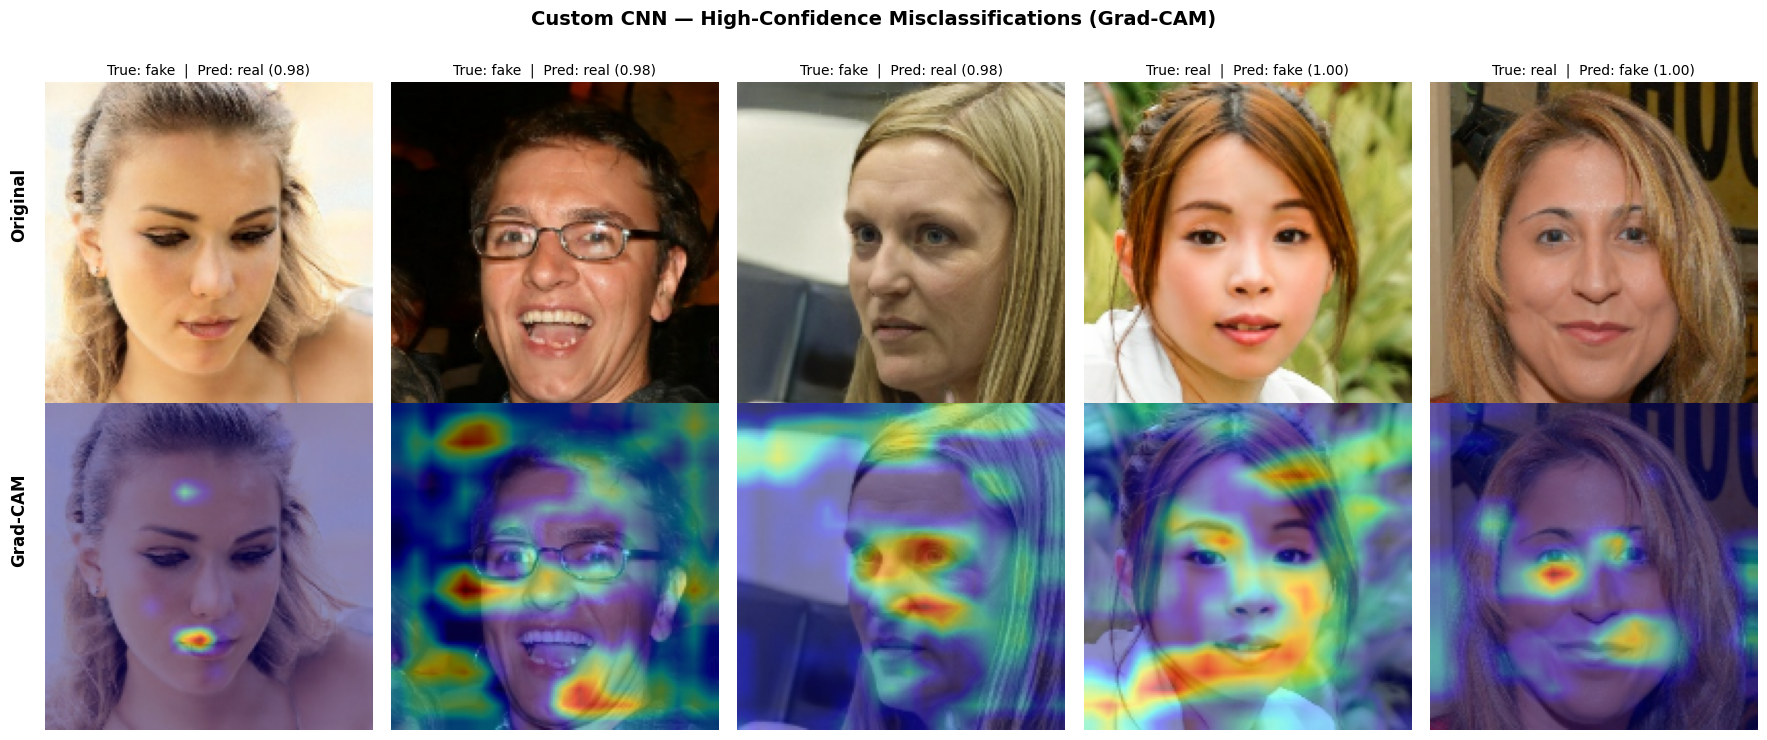

Saved: /kaggle/working/error_analysis_custom_cnn.png
